# Brazilian E-Commerce (Olist): Exploratory Data Analysis & Cleaning

**Phase 1 of 3:** Python (EDA & cleaning) → MySQL (relational analysis) → Tableau (dashboard)

This notebook profiles the nine tables of the [Olist Brazilian E-Commerce dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (~100k orders, 2016–2018), fixes data-quality issues, engineers delivery-timing features, and exports cleaned tables that feed the SQL analysis (`sql/olist_analysis_queries.sql`) and the Tableau dashboard.

**Central question:** what drives customer satisfaction, and where are the revenue and operational levers?

| # | Section | Focus |
|---|---------|-------|
| 1 | Setup & data loading | Imports, paths, raw tables |
| 2 | Product category translation | Portuguese → English lookup |
| 3 | Order details | Date parsing, delivery-time feature, order status |
| 4 | Order payments | Order value, payment types, installments |
| 5 | Geolocation | City-name normalization (accent fix) |
| 6 | Sellers | Seller concentration by zip code |
| 7 | Product details | Dimensions, volume, density, correlations |
| 8 | Customers | Unique vs. repeat customers, geography |
| 9 | Order items | Price, shipping cost, revenue by product & seller |
| 10 | Order reviews | Duplicate handling, review vs. delivery timing, significance test |
| 11 | Export | Cleaned tables → `data/*_updated.csv` |
| 12 | Load into MySQL | Cleaned tables → `Brazillian` schema for the SQL analysis |

## 1. Setup & Data Loading

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")  # Kaggle CSVs go here (see data/README.md)

In [2]:
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
geolocation = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
order_payment = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
order_details = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
product_category_name_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')
product_details = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
order_reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')

pd.DataFrame({
    name: [len(df), df.shape[1]]
    for name, df in {
        "customers": customers, "order_items": order_items, "geolocation": geolocation,
        "order_payment": order_payment, "order_details": order_details,
        "product_category_name_translation": product_category_name_translation,
        "product_details": product_details, "order_reviews": order_reviews, "sellers": sellers,
    }.items()
}, index=["rows", "columns"]).T

,rows,columns
customers,99441,5
order_items,112650,7
geolocation,1000163,5
order_payment,103886,5
order_details,99441,8
product_category_name_translation,71,2
product_details,32951,9
order_reviews,99224,7
sellers,3095,4


## 2. Product Category Translation

In [3]:
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty\r
1,informatica_acessorios,computers_accessories\r
2,automotivo,auto\r
3,cama_mesa_banho,bed_bath_table\r
4,moveis_decoracao,furniture_decor\r


In [4]:
product_category_name_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


**Data-quality issue:** the English category names carry a trailing carriage return (`'health_beauty\\r'`), which leaks into SQL results and Tableau labels. Strip whitespace from both columns:

In [5]:
print("Before:", repr(product_category_name_translation["product_category_name_english"].iloc[0]))

for col in ["product_category_name", "product_category_name_english"]:
    product_category_name_translation[col] = product_category_name_translation[col].str.strip()

print("After: ", repr(product_category_name_translation["product_category_name_english"].iloc[0]))

Before: 'health_beauty\r'
After:  'health_beauty'


## 3. Order Details

Parse all timestamp columns and engineer `delivery_days` (order approved → delivered to customer).

In [6]:
order_details.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
order_details["order_approved_at"] = pd.to_datetime(
    order_details["order_approved_at"],
    errors="coerce"
)

order_details["order_delivered_customer_date"] = pd.to_datetime(
    order_details["order_delivered_customer_date"],
    errors="coerce"
)

order_details["order_purchase_timestamp"] = pd.to_datetime(
    order_details["order_purchase_timestamp"],
    errors="coerce"
)

order_details["order_delivered_carrier_date"] = pd.to_datetime(
    order_details["order_delivered_carrier_date"],
    errors="coerce"
)

order_details["order_estimated_delivery_date"] = pd.to_datetime(
    order_details["order_estimated_delivery_date"],
    errors="coerce"
)

order_details["delivery_time"] = (
    order_details["order_delivered_customer_date"]
    - order_details["order_approved_at"]
)

In [8]:
order_details["delivery_days"] = (
    order_details["delivery_time"].dt.total_seconds() / 86400
)
order_details["delivery_days"] = order_details["delivery_days"].round(2)

In [9]:
order_details.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_days
count,99441,99281,97658,96476,99441,96462,96462.000000
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111,12 days 03:07:42.855694,12.130371
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,-7 days +00:14:54,-6.990000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00,6 days 07:26:16.250000,6.310000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,9 days 20:27:15.500000,9.850000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00,15 days 03:23:26.750000,15.140000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,208 days 12:01:24,208.500000
std,NaN,NaN,NaN,NaN,NaN,9 days 12:24:16.979327,9.516861


In [10]:
order_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  str            
 1   customer_id                    99441 non-null  str            
 2   order_status                   99441 non-null  str            
 3   order_purchase_timestamp       99441 non-null  datetime64[us] 
 4   order_approved_at              99281 non-null  datetime64[us] 
 5   order_delivered_carrier_date   97658 non-null  datetime64[us] 
 6   order_delivered_customer_date  96476 non-null  datetime64[us] 
 7   order_estimated_delivery_date  99441 non-null  datetime64[us] 
 8   delivery_time                  96462 non-null  timedelta64[us]
 9   delivery_days                  96462 non-null  float64        
dtypes: datetime64[us](5), float64(1), str(3), timedelta64[us](1)
memory usage: 7.6 MB

In [11]:
order_details["order_status"].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Orders with no customer delivery date, by status:

In [12]:
not_delivered = order_details[
    order_details["order_delivered_customer_date"].isna()
]

not_delivered["order_status"].value_counts(dropna=False)

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

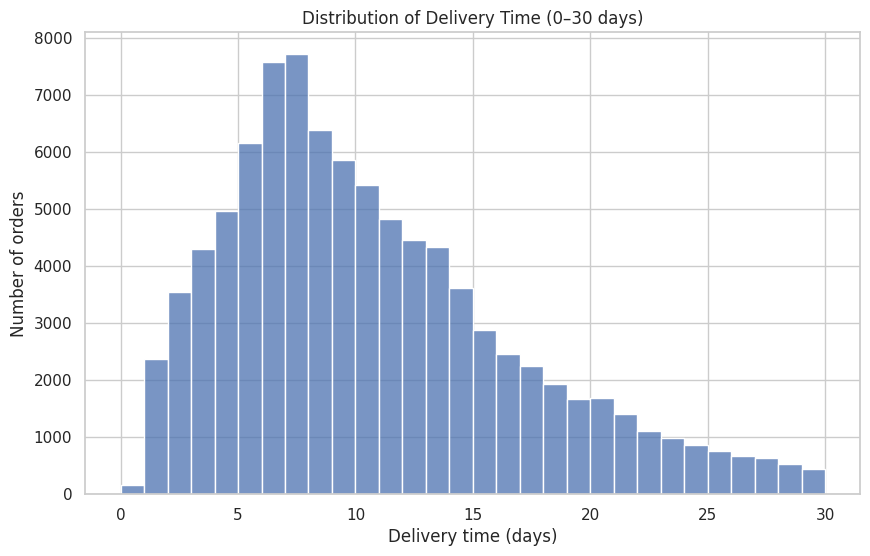

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_details[order_details["delivery_days"].between(0, 30)],
    x="delivery_days",
    bins=30
)

plt.title("Distribution of Delivery Time (0–30 days)")
plt.xlabel("Delivery time (days)")
plt.ylabel("Number of orders")
plt.show()

**Takeaways**
- 96,478 of 99,441 orders (97%) reached `delivered` status.
- Most orders arrive within 10 days of approval, with a long right tail.

## 4. Order Payments

In [14]:
order_payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [15]:
order_payment.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [16]:
order_payment.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


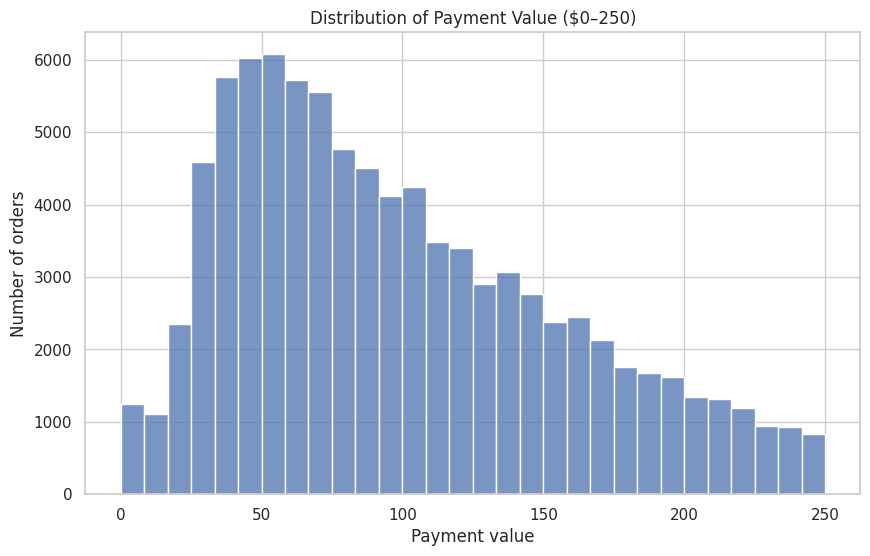

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_payment[order_payment["payment_value"].between(0, 250)],
    x="payment_value",
    bins=30
)

plt.title("Distribution of Payment Value ($0–250)")
plt.xlabel("Payment value")
plt.ylabel("Number of orders")
plt.show()

In [18]:
order_payment['payment_type'].value_counts(dropna=False)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [19]:
order_payment['payment_type'].describe()

count          103886
unique              5
top       credit_card
freq            76795
Name: payment_type, dtype: object

In [20]:
order_payment['payment_installments'].value_counts(dropna=False) 

payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644
12      133
15       74
18       27
11       23
24       18
20       17
13       16
14       15
17        8
16        5
21        3
0         2
22        1
23        1
Name: count, dtype: int64

**Takeaways**
- Mean order value is \$154.10; most payments cluster around \$50, with a maximum of \$13,664.
- Credit card dominates (76,795 payments), followed by boleto (19,784).
- 52,546 payments are made in a single installment; the tail extends to 24 installments.

## 5. Geolocation

In [21]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [22]:
geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [23]:
geolocation["geolocation_city"].value_counts()

geolocation_city
sao paulo                     135800
rio de janeiro                 62151
belo horizonte                 27805
são paulo                      24918
curitiba                       16593
                               ...  
são josé do herval                 1
almirante tamandaré do sul         1
são valentim                       1
três arroios                       1
ciríaco                            1
Name: count, Length: 8011, dtype: int64

In [24]:
geolocation[[
    "geolocation_lat",
    "geolocation_lng"
]].agg(["min", "max"])

,geolocation_lat,geolocation_lng
min,-36.605374,-101.466766
max,45.065933,121.105394


In [25]:
city_counts = geolocation["geolocation_city"].value_counts()

city_counts.head(10)  

geolocation_city
sao paulo                135800
rio de janeiro            62151
belo horizonte            27805
são paulo                 24918
curitiba                  16593
porto alegre              13521
salvador                  11865
guarulhos                 11340
brasilia                  10470
sao bernardo do campo      8112
Name: count, dtype: int64

**Data-quality issue:** "sao paulo" and "são paulo" are counted as separate cities because of inconsistent accents in the raw file. Normalize to lowercase ASCII:

In [26]:
geolocation["city_clean"] = (
    geolocation["geolocation_city"]
    .str.lower()
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

In [27]:
geolocation["city_clean"].value_counts().head(10)

city_clean
sao paulo                160719
rio de janeiro            62151
belo horizonte            27805
curitiba                  16593
porto alegre              13521
brasilia                  12650
salvador                  11866
guarulhos                 11340
sao bernardo do campo      9629
santo andre                8051
Name: count, dtype: int64

**Takeaway:** after normalization, Sao Paulo has **160,719** location records (vs. ~135,800 before the fix).

## 6. Sellers

In [28]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [29]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [30]:
sellers['seller_zip_code_prefix'].value_counts()

seller_zip_code_prefix
14940    49
13660    10
16200     9
13920     9
14020     8
         ..
5314      1
87111     1
4650      1
96080     1
12051     1
Name: count, Length: 2246, dtype: int64

**Takeaways**
- 3,095 sellers, heavily concentrated in SP state (1,849).
- Zip code 14940 alone hosts 49 sellers; the next-highest zip code has 10.

## 7. Product Details

In [31]:
product_details.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [32]:
product_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [33]:
widest_product = product_details.loc[
    product_details["product_weight_g"].idxmax()
]

widest_product

product_id                    26644690fde745fc4654719c3904e1db
product_category_name                          cama_mesa_banho
product_name_lenght                                       59.0
product_description_lenght                               534.0
product_photos_qty                                         1.0
product_weight_g                                       40425.0
product_length_cm                                         13.0
product_height_cm                                         65.0
product_width_cm                                          28.0
Name: 25166, dtype: object

In [34]:
product_details.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [35]:
product_details.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Engineer volume and density features to identify outlier products:

In [36]:
product_details["volume_cm3"] = (
    product_details["product_length_cm"]
    * product_details["product_height_cm"]
    * product_details["product_width_cm"]
)

In [37]:
product_details.nlargest(10, "volume_cm3")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3
12802,256a9c364b75753b97bee410c9491ad8,utilidades_domesticas,59.0,649.0,1.0,25250.0,68.0,66.0,66.0,296208.0
10697,0b48eade13cfad433122f23739a66898,moveis_decoracao,28.0,489.0,1.0,14000.0,70.0,60.0,70.0,294000.0
12146,f227e2d44f10f7dad30fb4dfa839e7a2,moveis_sala,51.0,795.0,1.0,30000.0,70.0,60.0,70.0,294000.0
17303,3eb14e65e4208c6d94b7a32e41add538,moveis_sala,51.0,1392.0,3.0,30000.0,70.0,60.0,70.0,294000.0
25524,c1e0531cb1864fd3a0cae57dca55ca80,moveis_sala,50.0,837.0,1.0,30000.0,70.0,60.0,70.0,294000.0
32532,90c1b4e040d1d1c45897ec2dad4a809d,moveis_sala,57.0,837.0,2.0,30000.0,63.0,63.0,74.0,293706.0
3770,c6fdec160d0f8f488d9041316c85051d,moveis_sala,57.0,1107.0,1.0,30000.0,80.0,60.0,60.0,288000.0
7234,8d6f2c3454002d3f5aa7479a7fad7794,moveis_sala,52.0,1105.0,1.0,30000.0,80.0,60.0,60.0,288000.0
16728,99ff40856c47a638df807c0a144470cc,moveis_sala,54.0,1108.0,2.0,30000.0,80.0,60.0,60.0,288000.0
28145,0e9dfb804bafa3d68ef3ee7a621abfb2,moveis_sala,17.0,531.0,3.0,30000.0,68.0,55.0,77.0,287980.0


In [38]:
product_details["density_g_cm3"] = (
    product_details["product_weight_g"] / product_details["volume_cm3"]
)

In [39]:
heaviest = product_details.loc[product_details["product_weight_g"].idxmax()]

tallest = product_details.loc[product_details["product_length_cm"].idxmax()]

most_photos = product_details.loc[product_details["product_photos_qty"].idxmax()]

biggest = product_details.loc[product_details["volume_cm3"].idxmax()]

densest = product_details.loc[product_details["density_g_cm3"].idxmax()]


print(f"heaviest = {heaviest}\n\ntallest = {tallest}\n\nmost_photos = {most_photos} \n\nbiggest = {biggest}\n\ndensest = {densest}")

heaviest = product_id                    26644690fde745fc4654719c3904e1db
product_category_name                          cama_mesa_banho
product_name_lenght                                       59.0
product_description_lenght                               534.0
product_photos_qty                                         1.0
product_weight_g                                       40425.0
product_length_cm                                         13.0
product_height_cm                                         65.0
product_width_cm                                          28.0
volume_cm3                                             23660.0
density_g_cm3                                          1.70858
Name: 25166, dtype: object

tallest = product_id                    7f34b85142d1ef9e077a0da9ada27385
product_category_name                         moveis_decoracao
product_name_lenght                                       59.0
product_description_lenght                              1750.0
produc

In [40]:
product_details[[
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].corr()

,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
product_photos_qty,1.000000,0.036539,0.067447,0.004000,0.026319
product_weight_g,0.036539,1.000000,0.476813,0.563910,0.527597
product_length_cm,0.067447,0.476813,1.000000,0.204889,0.542409
product_height_cm,0.004000,0.563910,0.204889,1.000000,0.313491
product_width_cm,0.026319,0.527597,0.542409,0.313491,1.000000


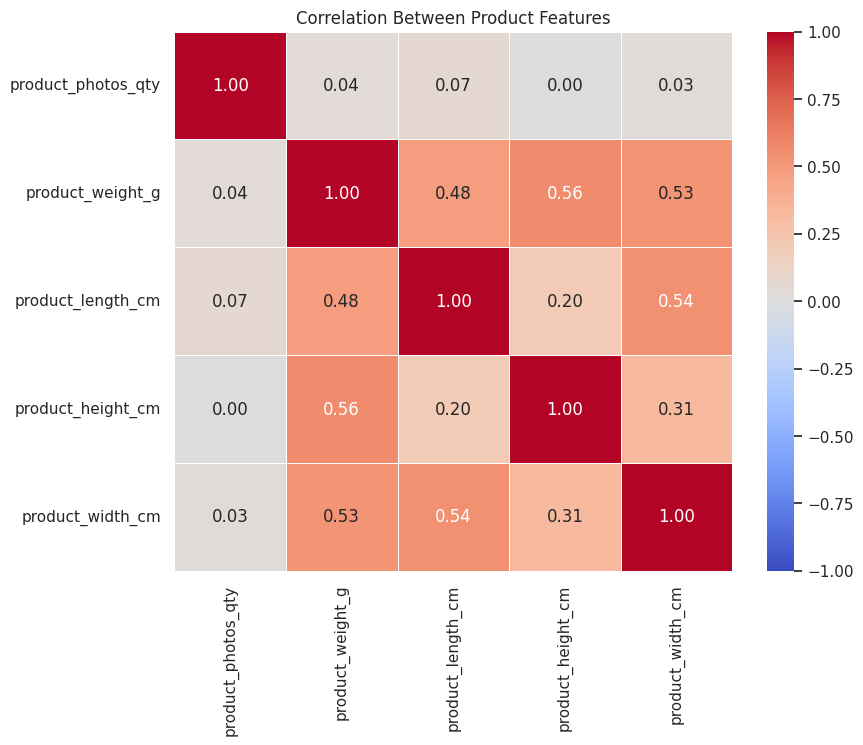

In [41]:
corr_matrix = product_details[[
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Between Product Features")
plt.show()

**Takeaways**
- 32,951 products across 73 categories (71 have English translations).
- Weight, length, height and width are moderately correlated (r ≈ 0.20–0.56); photo count is essentially uncorrelated with any physical dimension (r ≈ 0.00–0.07), as expected for a listing choice.

## 8. Customers

In [42]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [43]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [44]:
customers.rename(
    columns={"customer_zip_code_prefix": "zipcode"},
    inplace=True
)

In [45]:
customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [46]:
customers['customer_city'].value_counts()

customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64

In [47]:
customers['zipcode'].value_counts()

zipcode
22790    142
24220    124
22793    121
24230    117
22775    110
        ... 
87145      1
98860      1
5538       1
74980      1
99043      1
Name: count, Length: 14994, dtype: int64

`customer_id` is generated per order; `customer_unique_id` identifies the actual person:

In [48]:
print("Order records:", customers["customer_id"].nunique())
print("Unique customers:", customers["customer_unique_id"].nunique())

Order records: 99441
Unique customers: 96096


In [49]:
repeat_customers = customers["customer_unique_id"].value_counts()
repeat_customers[repeat_customers > 1].head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64

In [50]:
repeat_rate = (
    (repeat_customers > 1).sum()
    / customers["customer_unique_id"].nunique()
    * 100
)

print(f"Repeat-customer rate: {repeat_rate:.2f}%")

Repeat-customer rate: 3.12%


In [51]:
customers["customer_state"].value_counts(normalize=True).mul(100)

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
PE     1.661287
CE     1.343510
PA     0.980481
MT     0.912099
MA     0.751199
MS     0.719019
PB     0.539013
PI     0.497783
RN     0.487726
AL     0.415322
SE     0.351967
TO     0.281574
RO     0.254422
AM     0.148832
AC     0.081455
AP     0.068382
RR     0.046259
Name: proportion, dtype: float64

In [52]:
customers["customer_city"].value_counts(normalize=True).mul(100)

customer_city
sao paulo              15.627357
rio de janeiro          6.920687
belo horizonte          2.788588
brasilia                2.142979
curitiba                1.529550
                         ...    
siriji                  0.001006
natividade da serra     0.001006
monte bonito            0.001006
sao rafael              0.001006
eugenio de castro       0.001006
Name: proportion, Length: 4119, dtype: float64

**Takeaways**
- 99,441 order records map to 96,096 unique customers; the repeat-customer rate is only **3.12%**.
- ~42% of customers are in SP state and ~15.6% in Sao Paulo city; RJ is second (~13%).

## 9. Order Items

In [53]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [54]:
order_items.rename(
    columns={"freight_value": "shipping_cost"},
    inplace=True
)

In [55]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   shipping_cost        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [56]:
order_items.describe()

,order_item_id,price,shipping_cost
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


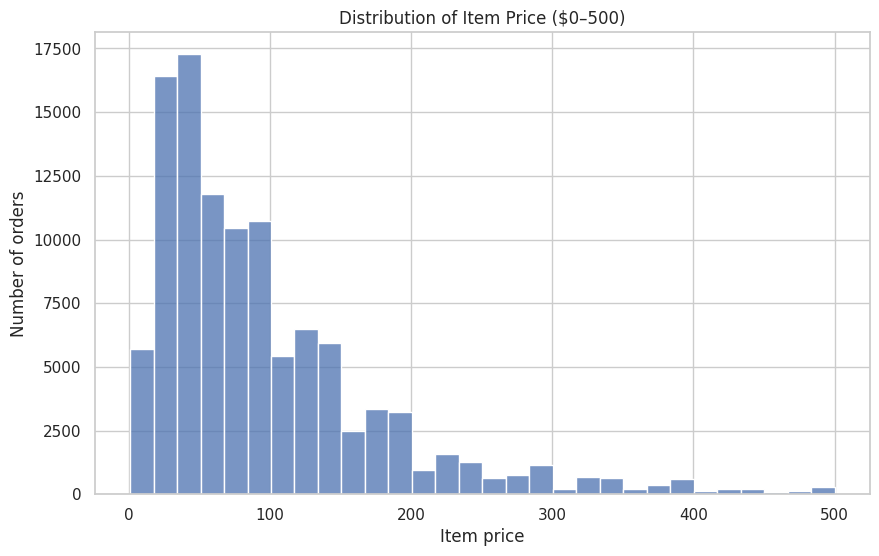

In [57]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_items[order_items["price"].between(0, 500)],
    x="price",
    bins=30
)

plt.title("Distribution of Item Price ($0–500)")
plt.xlabel("Item price")
plt.ylabel("Number of orders")
plt.show()

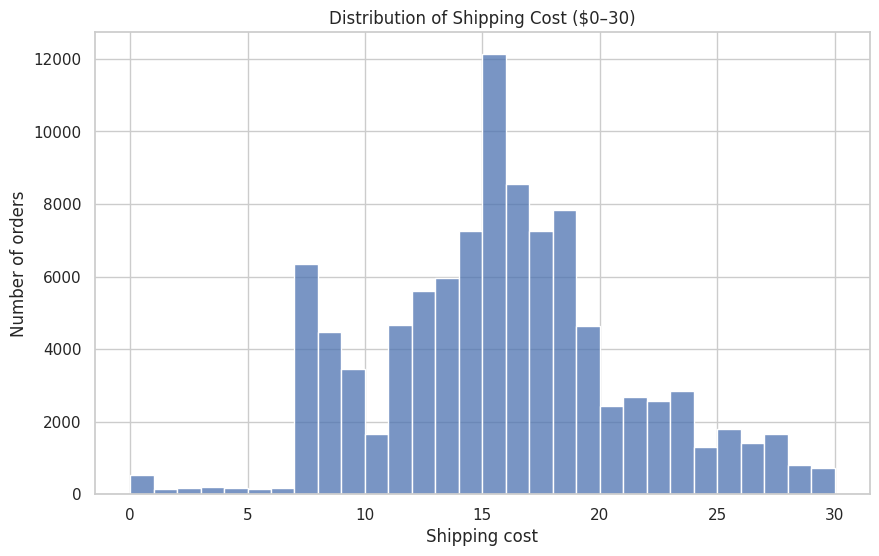

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_items[order_items["shipping_cost"].between(0, 30)],
    x="shipping_cost",
    bins=30
)

plt.title("Distribution of Shipping Cost ($0–30)")
plt.xlabel("Shipping cost")
plt.ylabel("Number of orders")
plt.show()

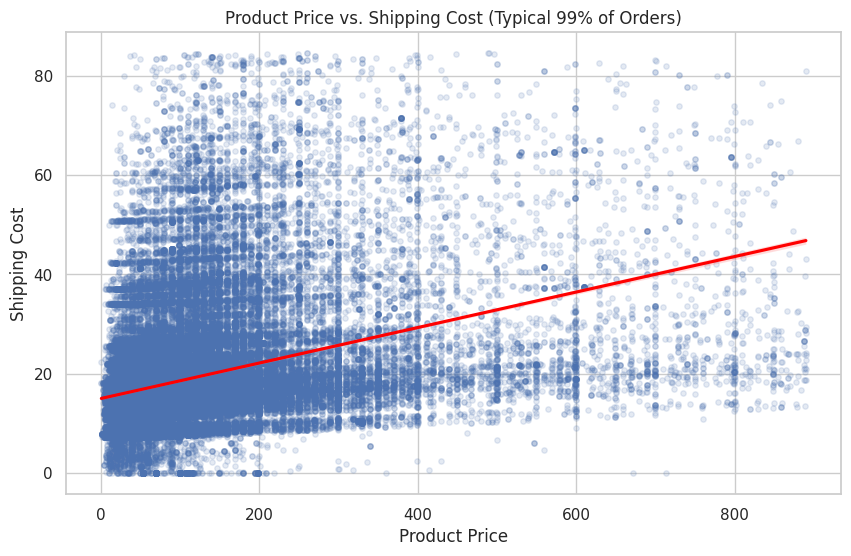

In [59]:
price_limit = order_items["price"].quantile(0.99)
shipping_limit = order_items["shipping_cost"].quantile(0.99)

typical_orders = order_items[
    (order_items["price"] <= price_limit) &
    (order_items["shipping_cost"] <= shipping_limit)
]

plt.figure(figsize=(10, 6))

sns.regplot(
    data=typical_orders,
    x="price",
    y="shipping_cost",
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Product Price vs. Shipping Cost (Typical 99% of Orders)")
plt.xlabel("Product Price")
plt.ylabel("Shipping Cost")
plt.show()

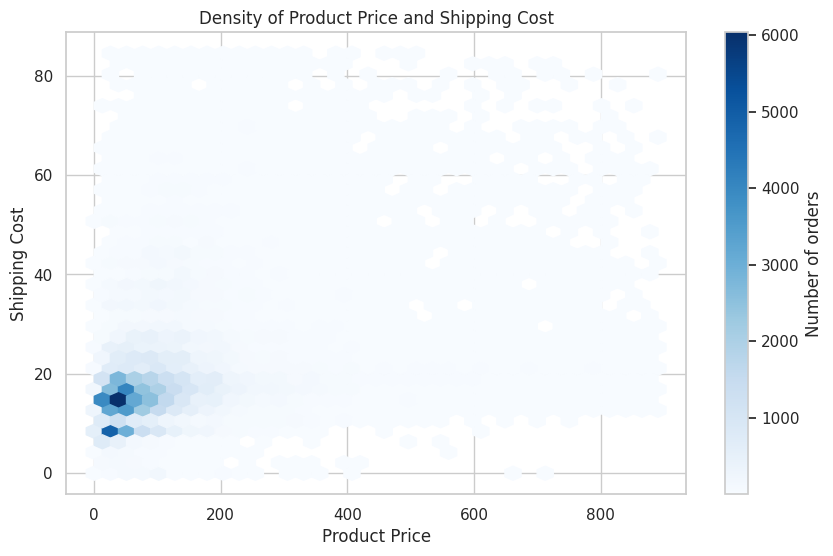

In [60]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    typical_orders["price"],
    typical_orders["shipping_cost"],
    gridsize=35,
    cmap="Blues",
    mincnt=1
)

plt.colorbar(label="Number of orders")
plt.title("Density of Product Price and Shipping Cost")
plt.xlabel("Product Price")
plt.ylabel("Shipping Cost")
plt.show()

In [61]:
items_per_order = order_items.groupby("order_id")["order_item_id"].count()

items_per_order.value_counts().sort_index()

order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [62]:
order_items["product_id"].value_counts().head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64

In [63]:
order_items["seller_id"].value_counts().head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

In [64]:
product_revenue = (
    order_items.groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64

In [65]:
seller_summary = (
    order_items.groupby("seller_id")
    .agg(
        items_sold=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        shipping_revenue=("shipping_cost", "sum"),
        average_price=("price", "mean")
    )
    .sort_values("product_revenue", ascending=False)
)

seller_summary.head(10)

,items_sold,product_revenue,shipping_revenue,average_price
seller_id,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,20168.07,198.505735
53243585a1d6dc2643021fd1853d8905,410,222776.05,13080.63,543.356220
4a3ca9315b744ce9f8e9374361493884,1987,200472.92,35067.04,100.892260
fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,10042.70,331.129744
7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,51612.55,137.774113
7e93a43ef30c4f03f38b393420bc753a,340,176431.87,6322.18,518.917265
da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,24955.75,103.311779
7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,20902.85,121.046567
1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,33892.14,97.316912


In [66]:
order_items["shipping_percent"] = (
    order_items["shipping_cost"] / order_items["price"] * 100
)

order_items[["price", "shipping_cost", "shipping_percent"]].describe()

,price,shipping_cost,shipping_percent
count,112650.000000,112650.000000,112650.000000
mean,120.653739,19.990320,32.086355
std,183.633928,15.806405,34.989368
min,0.850000,0.000000,0.000000
25%,39.900000,13.080000,13.403366
50%,74.990000,16.260000,23.135624
75%,134.900000,21.150000,39.303621
max,6735.000000,409.680000,2623.529412


In [67]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

**Takeaways**
- Mean item price \$120.65 (median \$74.99); mean shipping cost \$19.99 (median \$16.26).
- Shipping averages 32.1% of item price, a heavy relative cost on low-priced items.
- 88,863 orders contain a single item; the largest order has 21.

## 10. Order Reviews

In [68]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [69]:
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


### 10.1 Duplicate review IDs

Some `review_id`s appear on more than one order (the same review attached to several orders). To count each review once, keep the first occurrence **before** any review analysis. This keeps the Python results consistent with the SQL tables, which are built from the cleaned export.

In [70]:
order_reviews['review_id'].duplicated().sum()

np.int64(814)

In [71]:
dupes = order_reviews[order_reviews.duplicated(subset='review_id', keep=False)]
dupes.sort_values('review_id').head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [72]:
order_reviews = order_reviews.drop_duplicates(subset='review_id', keep='first')

In [73]:
order_reviews.shape[0]

98410

### 10.2 Review score distribution

In [74]:
order_reviews["review_score"].value_counts()

review_score
5    56910
4    19007
1    11282
3     8097
2     3114
Name: count, dtype: int64

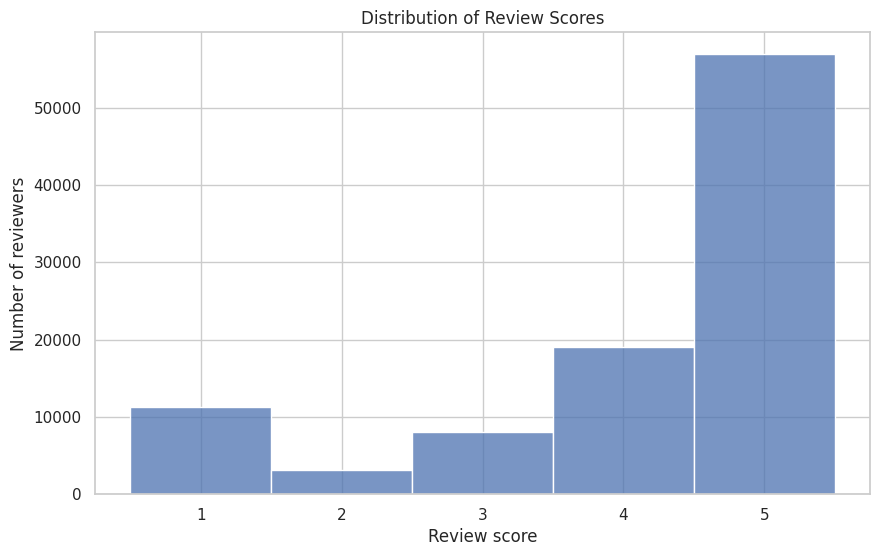

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=order_reviews,
    x="review_score",
    discrete=True
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review score")
plt.ylabel("Number of reviewers")
plt.show()

### 10.3 Low-rated orders (score ≤ 2)

In [76]:
low_reviews = order_reviews[order_reviews["review_score"] <= 2].copy()

low_reviews[[
    "review_id", "order_id", "review_score",
    "review_comment_title", "review_comment_message"
]].head()

,review_id,order_id,review_score,review_comment_title,review_comment_message
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo
29,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,NaN,Não gostei ! Comprei gato por lebre
32,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,NaN,Sempre compro pela Internet e a entrega ocorre...


In [77]:
low_reviews["has_comment"] = (
    low_reviews["review_comment_title"].notna()
    | low_reviews["review_comment_message"].notna()
)

low_reviews["has_comment"].value_counts(normalize=True).mul(100)

has_comment
True     75.444568
False    24.555432
Name: proportion, dtype: float64

In [78]:
low_review_orders = low_reviews.merge(
    order_details,
    on="order_id",
    how="left"
)

low_review_orders.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_comment,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_days
0,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37,False,eecafc3ff695f031bfe354a9fff9d437,delivered,2018-04-06 22:18:54,2018-04-09 20:10:35,2018-04-11 16:48:35,2018-04-12 17:17:53,2018-05-03,2 days 21:07:18,2.88
1,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2018-01-18 00:00:00,2018-01-20 21:25:45,True,db13a417a95ad304e9674468c17ade85,delivered,2017-12-19 13:14:37,2017-12-19 13:32:58,2017-12-20 20:28:58,2018-02-21 01:25:41,2018-01-17,63 days 11:52:43,63.49
2,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15 00:00:00,2018-08-15 04:10:37,True,e545e697bb9d1b81e0a702121d4e94d5,canceled,2018-08-04 19:25:07,2018-08-05 19:24:33,NaT,NaT,2018-08-13,NaT,NaN
3,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,NaN,Não gostei ! Comprei gato por lebre,2017-12-13 00:00:00,2017-12-16 07:14:07,True,5bb8de60ca2ca8b01a5ce471802fe10b,delivered,2017-11-24 01:40:48,2017-11-24 01:49:34,2017-12-06 15:19:09,2017-12-13 00:28:44,2017-12-19,18 days 22:39:10,18.94
4,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,NaN,Sempre compro pela Internet e a entrega ocorre...,2018-04-08 00:00:00,2018-04-09 12:22:39,True,30e6e854c81fa16f46a5d7f3ab025e6f,delivered,2018-03-16 12:51:35,2018-03-16 13:09:21,2018-03-20 18:32:31,2018-04-11 02:12:46,2018-04-06,25 days 13:03:25,25.54


Share of low reviews within each order status:

In [79]:
low_review_orders["order_status"].value_counts()


reviews_with_orders = order_reviews.merge(order_details, on="order_id", how="left")

pd.crosstab(
    reviews_with_orders["order_status"],
    reviews_with_orders["review_score"] <= 2,
    normalize="index"
).mul(100)

review_score,False,True
order_status,,
approved,50.000000,50.000000
canceled,22.010399,77.989601
created,33.333333,66.666667
delivered,87.239695,12.760305
invoiced,16.883117,83.116883
processing,7.482993,92.517007
shipped,30.671860,69.328140
unavailable,14.745763,85.254237


In [80]:
for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    low_review_orders[col] = pd.to_datetime(low_review_orders[col])

low_review_orders["delivery_delay_days"] = (
    low_review_orders["order_delivered_customer_date"]
    - low_review_orders["order_estimated_delivery_date"]
).dt.days

In [81]:
low_review_orders['delivery_delay_days'].describe()

count    12203.000000
mean        -5.115545
std         15.458700
min        -69.000000
25%        -15.000000
50%         -8.000000
75%          5.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

In [82]:
late_rate = (
    (low_review_orders["delivery_delay_days"] > 0).mean() * 100
)

print(f"{late_rate:.2f}% of low-rated orders were delivered late.")

27.58% of low-rated orders were delivered late.


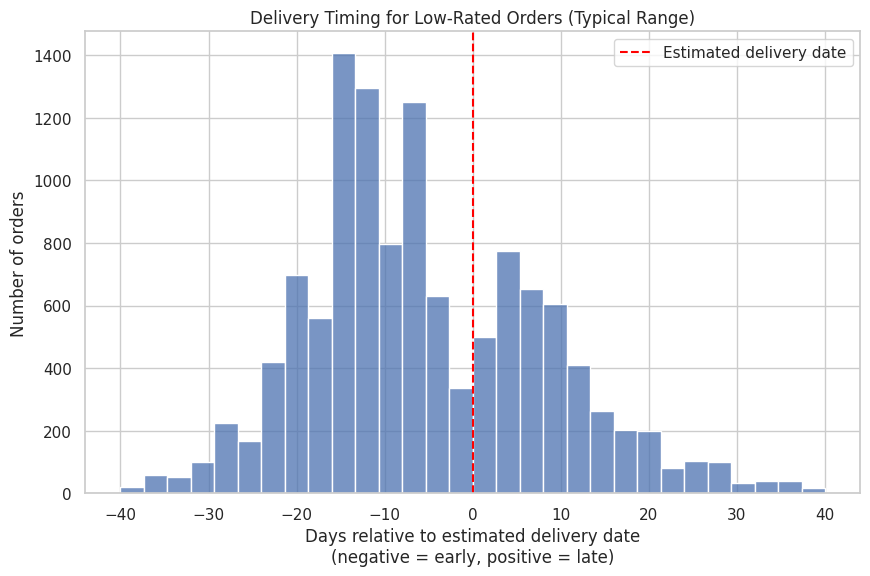

In [83]:
typical_low_reviews = low_review_orders[
    low_review_orders["delivery_delay_days"].between(-40, 40)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=typical_low_reviews,
    x="delivery_delay_days",
    bins=30
)

plt.axvline(0, color="red", linestyle="--", label="Estimated delivery date")
plt.title("Delivery Timing for Low-Rated Orders (Typical Range)")
plt.xlabel("Days relative to estimated delivery date\n(negative = early, positive = late)")
plt.ylabel("Number of orders")
plt.legend()
plt.show()

### 10.4 Delivery timing across all review scores

Average days relative to the estimated delivery date for each review score (negative = early, positive = late):

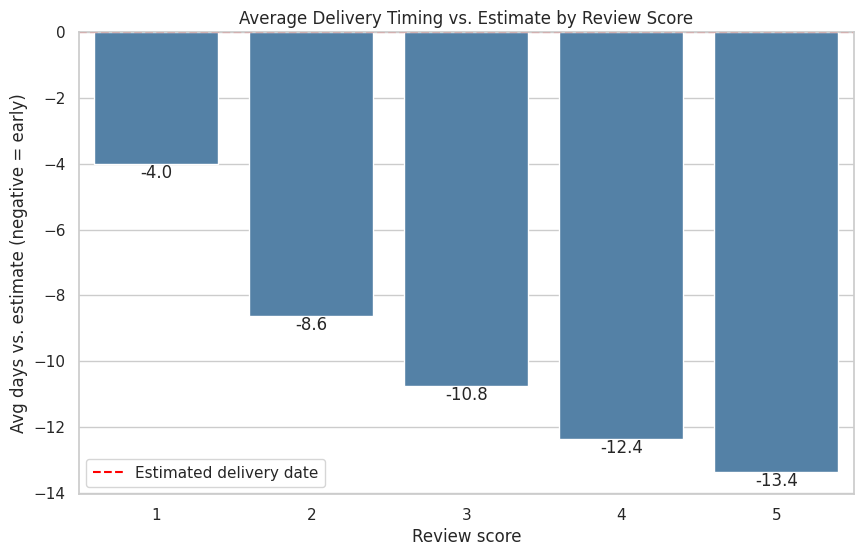

review_score
1    -4.0
2    -8.6
3   -10.8
4   -12.4
5   -13.4
Name: days_vs_estimate, dtype: float64

In [84]:
reviews_delivered = reviews_with_orders[
    reviews_with_orders["order_delivered_customer_date"].notna()
].copy()

reviews_delivered["days_vs_estimate"] = (
    pd.to_datetime(reviews_delivered["order_delivered_customer_date"]).dt.normalize()
    - pd.to_datetime(reviews_delivered["order_estimated_delivery_date"]).dt.normalize()
).dt.days

by_score = reviews_delivered.groupby("review_score")["days_vs_estimate"].mean()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=by_score.index, y=by_score.values, color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.1f")
plt.axhline(0, color="red", linestyle="--", label="Estimated delivery date")
plt.title("Average Delivery Timing vs. Estimate by Review Score")
plt.xlabel("Review score")
plt.ylabel("Avg days vs. estimate (negative = early)")
plt.legend()
plt.show()

by_score.round(1)

### 10.5 Is the gap statistically significant?

Welch's independent-samples t-test comparing days-vs-estimate for high (3–5) and low (1–2) reviews:

In [85]:
high = reviews_delivered.loc[reviews_delivered["review_score"] >= 3, "days_vs_estimate"]
low = reviews_delivered.loc[reviews_delivered["review_score"] <= 2, "days_vs_estimate"]

t_stat, p_value = stats.ttest_ind(high, low, equal_var=False)

print(f"High reviews: mean {high.mean():.1f} days vs. estimate (n = {len(high):,})")
print(f"Low reviews:  mean {low.mean():.1f} days vs. estimate (n = {len(low):,})")
print(f"Welch's t = {t_stat:.2f}, p {'< 0.0001' if p_value < 1e-4 else f'= {p_value:.4f}'}")

High reviews: mean -12.9 days vs. estimate (n = 83,404)
Low reviews:  mean -5.1 days vs. estimate (n = 12,203)
Welch's t = -54.44, p < 0.0001


**Takeaways**
- Scores skew heavily to 5 stars, with a secondary spike at 1 star.
- **27.58% of low-rated orders were delivered after the estimated date**, and ~75% of low reviews include a written comment.
- Non-delivered statuses (canceled, unavailable, processing, invoiced) have far higher low-review shares than delivered orders.
- High-rated orders arrive ~12.9 days early on average vs. ~5.1 days for low-rated orders. The difference is highly significant (Welch's t = −54.44, p < 0.0001): **delivery performance is the clearest satisfaction lever in the data.**

## 11. Export Cleaned Tables

The cleaned tables are saved next to the raw files in `data/` with an `_updated` suffix. They feed MySQL (section 12) and the Tableau dashboard.

In [86]:
cleaned_tables = {
    "customers_updated": customers,
    "geolocation_updated": geolocation,
    "order_details_updated": order_details,
    "order_items_updated": order_items,
    "order_payments_updated": order_payment,
    "order_reviews_updated": order_reviews,
    "product_category_name_translation_updated": product_category_name_translation,
    "product_details_updated": product_details,
    "sellers_updated": sellers,
}

for name, df in cleaned_tables.items():
    df.to_csv(DATA_DIR / f"{name}.csv", index=False)

pd.Series({name: len(df) for name, df in cleaned_tables.items()}, name="rows exported")

customers_updated                              99441
geolocation_updated                          1000163
order_details_updated                          99441
order_items_updated                           112650
order_payments_updated                        103886
order_reviews_updated                          98410
product_category_name_translation_updated         71
product_details_updated                        32951
sellers_updated                                 3095
Name: rows exported, dtype: int64

## 12. Load into MySQL

The cleaned DataFrames are pushed straight into the MySQL schema `Brazillian` with SQLAlchemy's `to_sql()`. This is more reliable than MySQL Workbench's import wizard, which hit UTF-8/BOM encoding errors and `LOAD DATA LOCAL INFILE` restrictions.

> Run this cell locally after setting `MYSQL_USER` and `MYSQL_PASSWORD` as environment variables. Requires `SQLAlchemy` and `PyMySQL`.

In [ ]:
import os
from sqlalchemy import create_engine

engine = create_engine(
    f"mysql+pymysql://{os.environ['MYSQL_USER']}:{os.environ['MYSQL_PASSWORD']}"
    "@localhost/Brazillian?charset=utf8mb4"
)

# MySQL table names used in sql/olist_analysis_queries.sql
mysql_tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_details": order_details.drop(columns="delivery_time"),  # Timedelta not supported; delivery_days is kept
    "order_items": order_items,
    "order_payments": order_payment,
    "order_reviews": order_reviews,
    "product_category_name_translation": product_category_name_translation,
    "product_details": product_details,
    "sellers": sellers,
}

for table, df in mysql_tables.items():
    df.to_sql(table, engine, if_exists="replace", index=False, chunksize=10_000)
    print(f"{table:<35} {len(df):>9,} rows")

## Next Step: SQL Analysis

With the tables in MySQL, the business questions are answered in [`sql/olist_analysis_queries.sql`](../sql/olist_analysis_queries.sql):

| # | Question |
|---|----------|
| Q1 | How does review score relate to delivery timing? |
| Q2 | Which city generates the most revenue? |
| Q3 | Which product categories are in highest demand? |
| Q4 | How do sellers compare on volume vs. satisfaction? |
| Q5 | How do shipping cost and delivery time vary by state? |
| Q6 | Which products generate the most revenue, and where do they sell from? |
| Q7 | Which zip codes perform best? |
| Q8 | How much revenue comes from repeat vs. one-time customers? |
| Q9 | Which states have the highest order failure rate? |
| Q10 | Which month had the highest order volume and revenue? |

Results and recommendations are summarized in [`reports/key_findings.md`](../reports/key_findings.md).